# Convolutional Neural Network for Sign Language MNIST
## About this dataset

The original MNIST image dataset of handwritten digits is a popular benchmark for image-based machine learning methods but researchers have renewed efforts to update it and develop drop-in replacements that are more challenging for computer vision and original for real-world applications. As noted in one recent replacement called the Fashion-MNIST dataset, the Zalando researchers quoted the startling claim that "Most pairs of MNIST digits (784 total pixels per sample) can be distinguished pretty well by just one pixel". To stimulate the community to develop more drop-in replacements, the Sign Language MNIST is presented here and follows the same CSV format with labels and pixel values in single rows. The American Sign Language letter database of hand gestures represent a multi-class problem with 24 classes of letters (excluding J and Z which require motion).




In [1]:
from google.colab import drive
drive.mount('/content/drive')
data_path="drive/MyDrive/Colab Notebooks/504project/"
%cd $data_path

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/504project


## Importing dependencies


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


## Specifying paths and training hyperparameters


In [ ]:
TRAIN_PATH = 'data/sign_mnist_train.csv'
VALID_PATH = 'data/sign_mnist_test.csv'

INPUT_SHAPE = (28, 28, 1)
EPOCHS = 8
BATCH_SIZE = 128
LEARNING_RATE = 1e-3


## Reading the data


In [ ]:
trainData = pd.read_csv(TRAIN_PATH)
validData = pd.read_csv(VALID_PATH)

NO_CLASSES = int(max(trainData['label'].max(), validData['label'].max()) + 1)
print(f'Train samples: {len(trainData)}, Valid samples: {len(validData)}, Classes: {NO_CLASSES}')


Train samples: 27455, Valid samples: 7172, Classes: 25


## Transforming and scaling the data


In [ ]:
x_train = np.array(trainData.drop(columns=['label']), dtype=np.float32)
y_train = np.array(trainData['label'], dtype=np.int32)
x_valid = np.array(validData.drop(columns=['label']), dtype=np.float32)
y_valid = np.array(validData['label'], dtype=np.int32)


## Scaling the data for computational efficiency

In [ ]:
x_train = x_train.reshape(len(x_train), 28, 28, 1) / 255.0
x_valid = x_valid.reshape(len(x_valid), 28, 28, 1) / 255.0

x_train.shape, y_train.shape, x_valid.shape, y_valid.shape


((27455, 28, 28, 1), (27455,), (7172, 28, 28, 1), (7172,))

## Model architectures (ResNet + baselines for comparison)


In [ ]:
def make_mobilenet_small():
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.Resizing(96, 96)(inputs)
    x = layers.Concatenate()([x, x, x])
    x = layers.Lambda(lambda t: (t * 2.0) - 1.0)(x)
    data_augmentation = keras.Sequential(
        [
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.05),
            layers.RandomTranslation(0.05, 0.05),
        ],
        name='mobilenet_aug',
    )
    x = data_augmentation(x)
    base_model = keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights='imagenet',
    )
    base_model.trainable = False
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='mobilenet_small')


def residual_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)


def make_resnet_small():
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='resnet_small')


def make_vgg_tiny():
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='vgg_tiny')


def make_basic_cnn():
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='basic_cnn')


MODEL_BUILDERS = {
    'resnet_small': make_resnet_small,
    'mobilenet_small': make_mobilenet_small,
    'vgg_tiny': make_vgg_tiny,
    'basic_cnn': make_basic_cnn,
}


## Train and compare architectures


In [ ]:
histories = {}
trained_models = {}
results = []

for model_name, builder in MODEL_BUILDERS.items():
    print(f'\n===== Training: {model_name} =====')
    model_i = builder()
    model_i.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        metrics=['accuracy'],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=2,
            mode='max',
            restore_best_weights=True,
        )
    ]

    history_i = model_i.fit(
        x_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_valid, y_valid),
        callbacks=callbacks,
        verbose=1,
    )

    final_train_loss = float(history_i.history['loss'][-1])
    final_train_acc = float(history_i.history['accuracy'][-1])
    final_val_loss = float(history_i.history['val_loss'][-1])
    final_val_acc = float(history_i.history['val_accuracy'][-1])

    histories[model_name] = history_i
    trained_models[model_name] = model_i
    results.append(
        {
            'model': model_name,
            'train_acc': final_train_acc,
            'train_loss': final_train_loss,
            'val_acc': final_val_acc,
            'val_loss': final_val_loss,
            'params': int(model_i.count_params()),
        }
    )

results_df = pd.DataFrame(results).sort_values('val_acc', ascending=False).reset_index(drop=True)
results_df[['train_acc', 'train_loss', 'val_acc', 'val_loss']] = results_df[
    ['train_acc', 'train_loss', 'val_acc', 'val_loss']
].round(4)
results_df



===== Training: resnet_small =====
Epoch 1/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.7995 - loss: 0.7075 - val_accuracy: 0.0287 - val_loss: 9.6807
Epoch 2/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9998 - loss: 0.0080 - val_accuracy: 0.4778 - val_loss: 2.1445
Epoch 3/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9823 - val_loss: 0.0618
Epoch 4/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9887 - loss: 0.0462 - val_accuracy: 0.8730 - val_loss: 0.5661
Epoch 5/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9941 - val_loss: 0.0190
Epoch 6/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 8.2277e-04 - val_accuracy: 0.9979 - val_loss: 0.0143
Epoch 7/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 5.4695e-04 - val_accuracy: 0.9962 - val_loss: 0.0148
Epoch 8/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.

,model,train_acc,train_loss,val_acc,val_loss,params
0,resnet_small,1.0000,0.0005,0.9972,0.0137,681529
1,mobilenet_small,0.9648,0.1250,0.9794,0.0762,2290009
2,vgg_tiny,0.9808,0.0655,0.9678,0.0703,142073
3,basic_cnn,0.9887,0.0370,0.9426,0.2010,243481


### `results_df` gives the validation comparison. For this project, use `resnet_small` as the main architecture and report other models as baselines.


## Pick best model and save


In [ ]:
best_model_name = results_df.loc[0, 'model']
model = trained_models[best_model_name]
model.save(f'sign_language_{best_model_name}.keras')
print(f'Best model: {best_model_name}')

sample_idx = 0
testImage = x_valid[sample_idx]
prediction = model.predict(testImage.reshape(-1, 28, 28, 1), verbose=0)


Best model: resnet_small


## Display prediction result


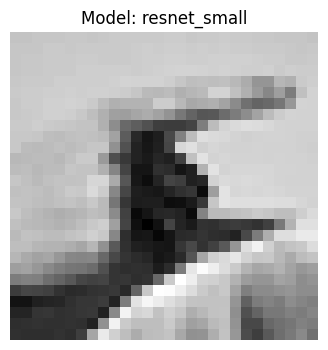

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(testImage.reshape(28, 28), cmap='gray')
plt.title(f'Model: {best_model_name}')
plt.xlabel(f'Prediction: {np.argmax(prediction)}, Actual: {y_valid[sample_idx]}')
plt.axis('off')
plt.show()


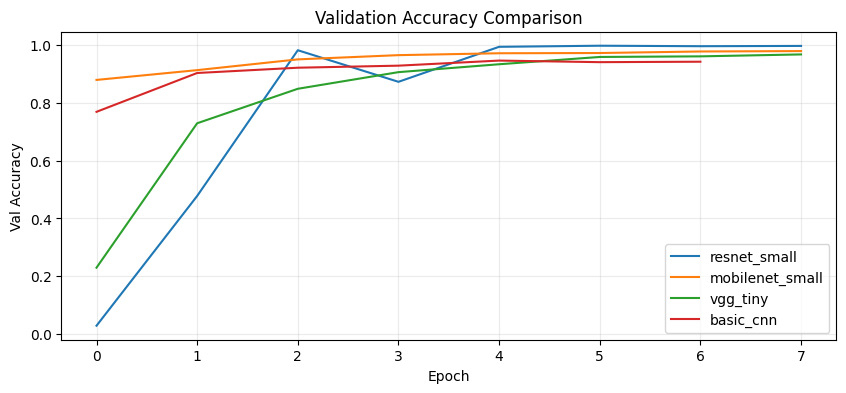

In [ ]:
plt.figure(figsize=(10, 4))
for model_name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=model_name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## ResNet Hyperparameter Tuning (Key Params)

We tune `resnet_small` with several key hyperparameters:
- learning rate
- batch size
- dropout rate


In [ ]:
# A tunable ResNet builder (same backbone, configurable dropout)
def make_resnet_tuned(dropout_rate=0.3):
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='resnet_tuned')


resnet_tune_configs = [
    {'name': 'base', 'lr': 1e-3, 'batch_size': 128, 'dropout': 0.30},
    {'name': 'low_lr', 'lr': 3e-4, 'batch_size': 128, 'dropout': 0.30},
    {'name': 'small_batch', 'lr': 1e-3, 'batch_size': 64, 'dropout': 0.30},
    {'name': 'strong_dropout', 'lr': 1e-3, 'batch_size': 128, 'dropout': 0.45},
    {'name': 'low_lr_small_batch', 'lr': 3e-4, 'batch_size': 64, 'dropout': 0.45},
]

resnet_tune_results = []
resnet_tune_histories = {}

for cfg in resnet_tune_configs:
    print(f"\n===== ResNet tune: {cfg['name']} =====")
    model_t = make_resnet_tuned(dropout_rate=cfg['dropout'])
    model_t.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
        metrics=['accuracy'],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=3,
            mode='max',
            restore_best_weights=True,
        )
    ]

    hist_t = model_t.fit(
        x_train,
        y_train,
        epochs=EPOCHS,
        batch_size=cfg['batch_size'],
        validation_data=(x_valid, y_valid),
        callbacks=callbacks,
        verbose=1,
    )

    resnet_tune_histories[cfg['name']] = hist_t

    resnet_tune_results.append(
        {
            'setting': cfg['name'],
            'lr': cfg['lr'],
            'batch_size': cfg['batch_size'],
            'dropout': cfg['dropout'],
            'train_acc': float(hist_t.history['accuracy'][-1]),
            'train_loss': float(hist_t.history['loss'][-1]),
            'val_acc': float(hist_t.history['val_accuracy'][-1]),
            'val_loss': float(hist_t.history['val_loss'][-1]),
            'best_val_acc': float(np.max(hist_t.history['val_accuracy'])),
            'params': int(model_t.count_params()),
        }
    )

resnet_tune_df = pd.DataFrame(resnet_tune_results).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
resnet_tune_df[['train_acc', 'train_loss', 'val_acc', 'val_loss', 'best_val_acc']] = resnet_tune_df[
    ['train_acc', 'train_loss', 'val_acc', 'val_loss', 'best_val_acc']
].round(4)

resnet_tune_df



===== ResNet tune: base =====
Epoch 1/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.8436 - loss: 0.5703 - val_accuracy: 0.0503 - val_loss: 5.3875
Epoch 2/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9999 - loss: 0.0074 - val_accuracy: 0.6369 - val_loss: 1.2417
Epoch 3/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9709 - val_loss: 0.0989
Epoch 4/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9998 - loss: 0.0024 - val_accuracy: 0.4109 - val_loss: 2.8992
Epoch 5/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9884 - loss: 0.0461 - val_accuracy: 0.9833 - val_loss: 0.0580
Epoch 6/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9967 - val_loss: 0.0142
Epoch 7/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 7.7007e-04 - val_accuracy: 0.9983 - val_loss: 0.0089
Epoch 8/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - lo

,setting,lr,batch_size,dropout,train_acc,train_loss,val_acc,val_loss,best_val_acc,params
0,small_batch,0.0010,64,0.30,1.0,0.0002,0.9985,0.0072,1.0000,681529
1,base,0.0010,128,0.30,1.0,0.0005,0.9992,0.0073,0.9992,681529
2,strong_dropout,0.0010,128,0.45,1.0,0.0008,0.9974,0.0111,0.9974,681529
3,low_lr_small_batch,0.0003,64,0.45,1.0,0.0023,0.9968,0.0154,0.9968,681529
4,low_lr,0.0003,128,0.30,1.0,0.0019,0.9877,0.0411,0.9902,681529


## Confusion Matrix (Best Overall Model)


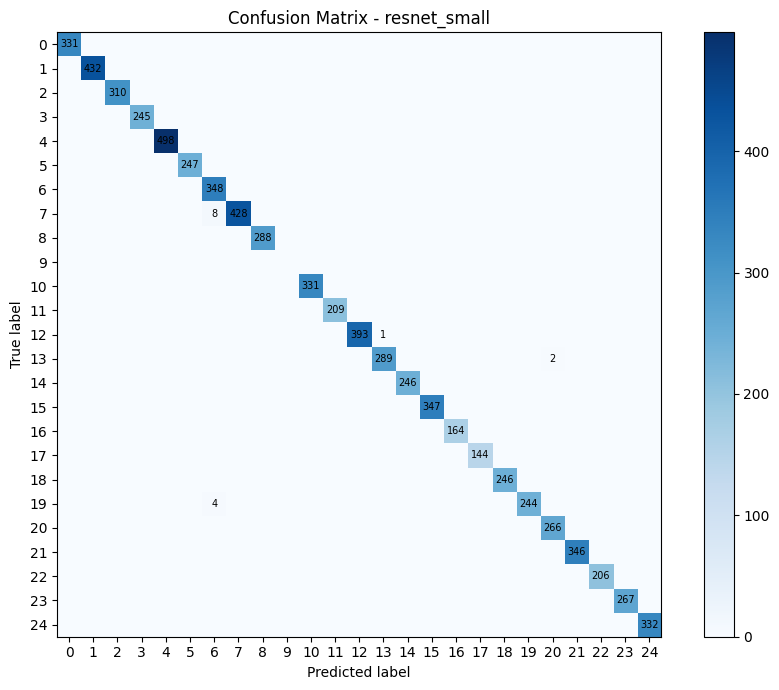

In [ ]:
y_pred_prob = model.predict(x_valid, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Use TensorFlow confusion matrix to avoid extra dependencies
cm = tf.math.confusion_matrix(y_valid, y_pred, num_classes=NO_CLASSES).numpy()

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')

tick_marks = np.arange(NO_CLASSES)
plt.xticks(tick_marks)
plt.yticks(tick_marks)

# annotate non-zero entries
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            plt.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()


## Testing

### val set

Loaded: resnet_small


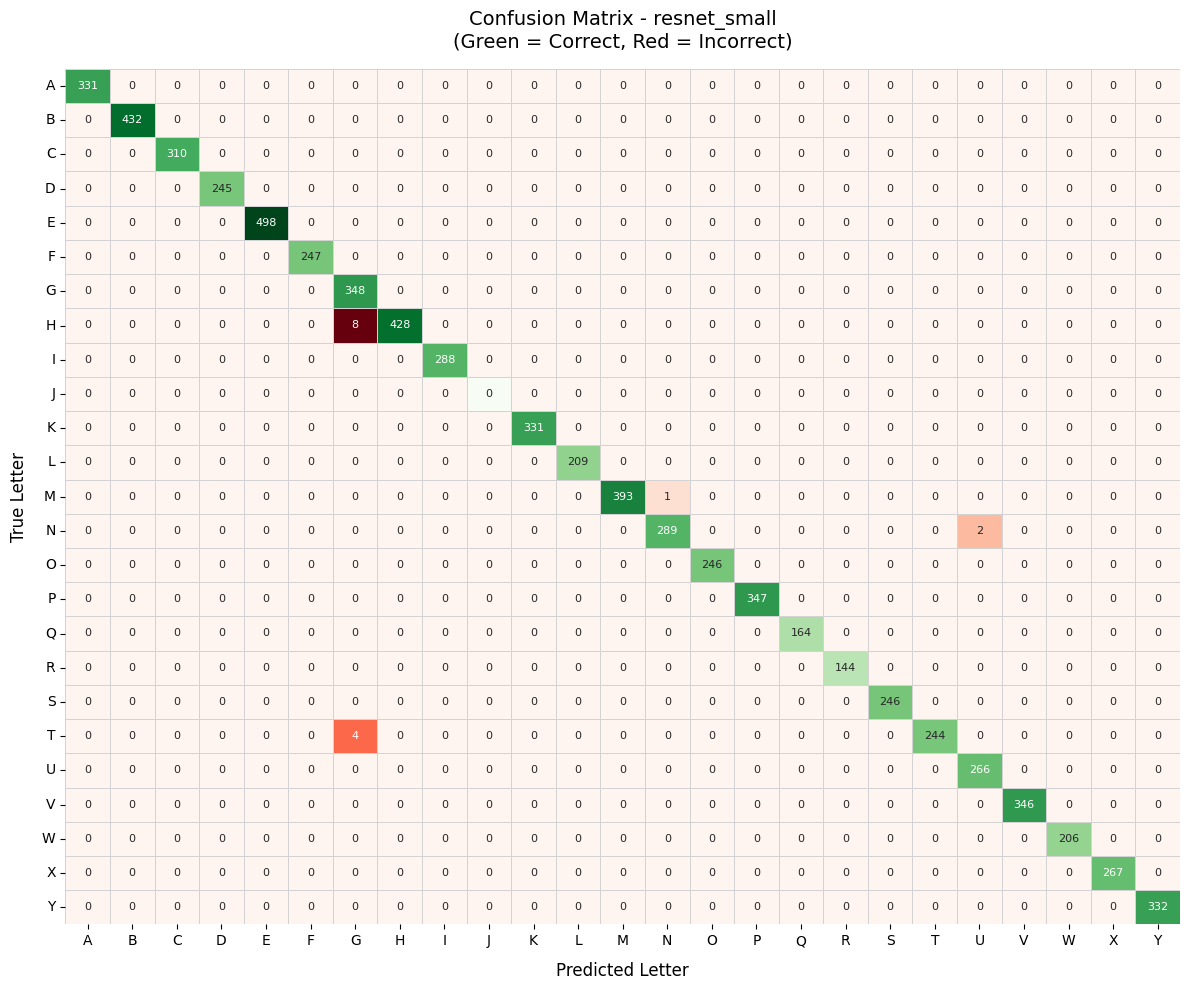

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

VALID_PATH = 'data/sign_mnist_test.csv'
valid_df = pd.read_csv(VALID_PATH)
x_valid = np.array(valid_df.drop(columns=['label']), dtype=np.float32)
y_valid = np.array(valid_df['label'], dtype=np.int32)
x_valid = x_valid.reshape(len(x_valid), 28, 28, 1) / 255.0
NO_CLASSES = int(valid_df['label'].max() + 1)
best_model_name = 'resnet_small'
model = keras.models.load_model(f'sign_language_{best_model_name}.keras')
print(f"Loaded: {best_model_name}")
y_pred_probs = model.predict(x_valid, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_valid, y_pred, labels=range(NO_CLASSES))
class_names = [chr(ord('A') + i) for i in range(NO_CLASSES)]
fig, ax = plt.subplots(figsize=(12, 10))
mask_diag = np.eye(NO_CLASSES, dtype=bool)
mask_off_diag = ~mask_diag
sns.heatmap(cm, mask=mask_diag, cmap='Reds', cbar=False,
            annot=True, fmt='d', annot_kws={"size": 8}, ax=ax,
            linewidths=0.5, linecolor='lightgray')
sns.heatmap(cm, mask=mask_off_diag, cmap='Greens', cbar=False,
            annot=True, fmt='d', annot_kws={"size": 8}, ax=ax,
            linewidths=0.5, linecolor='lightgray')
ax.set_xticks(np.arange(NO_CLASSES) + 0.5)
ax.set_yticks(np.arange(NO_CLASSES) + 0.5)
ax.set_xticklabels(class_names, rotation=0)
ax.set_yticklabels(class_names, rotation=0)
ax.set_title(f'Confusion Matrix - {best_model_name}\n(Green = Correct, Red = Incorrect)', fontsize=14, pad=15)
ax.set_xlabel('Predicted Letter', fontsize=12, labelpad=10)
ax.set_ylabel('True Letter', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

### real images

Loaded: sign_language_resnet_small.keras

Dataset: 10 | Accuracy: 80.00%



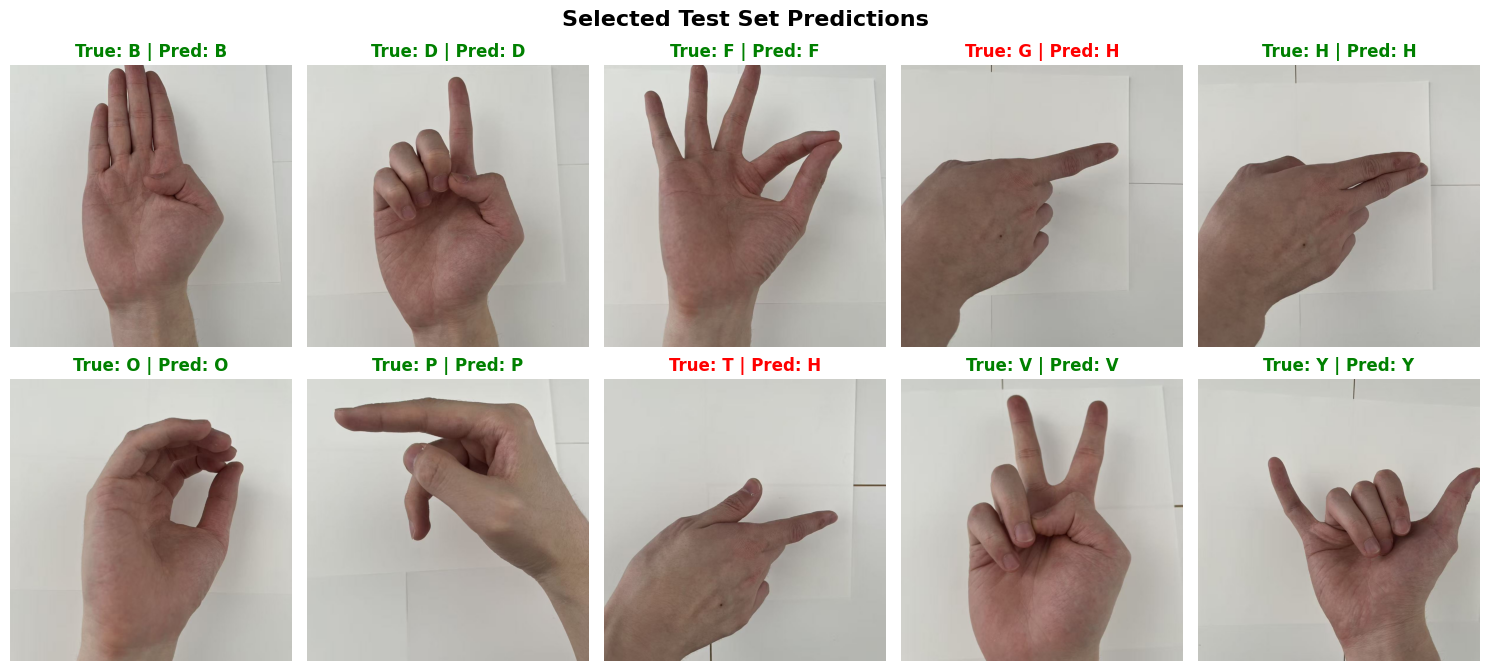

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

TEST_DIR = 'data/photo'
MODEL_PATH = 'sign_language_resnet_small.keras'
model = keras.models.load_model(MODEL_PATH)
print(f"Loaded: {MODEL_PATH}")
target_chars = ['G', 'T', 'B', 'D', 'F', 'H', 'O', 'P', 'V', 'Y']
image_files = [f for f in os.listdir(TEST_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
results = []
for filename in image_files:
    true_char = filename.split('.')[0].upper()
    if true_char not in target_chars:
        continue
    true_label = ord(true_char) - ord('A')
    filepath = os.path.join(TEST_DIR, filename)
    img_orig = cv2.imread(filepath)
    if img_orig is None:
        continue
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    h, w = img_orig.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    img_cropped = img_orig[start_y:start_y+min_dim, start_x:start_x+min_dim]
    img_gray = cv2.cvtColor(img_cropped, cv2.COLOR_RGB2GRAY)
    img_resized = cv2.resize(img_gray, (28, 28))
    img_model_input = img_resized.reshape(1, 28, 28, 1) / 255.0
    pred_probs = model.predict(img_model_input, verbose=0)
    pred_label = np.argmax(pred_probs, axis=1)[0]
    pred_char = chr(ord('A') + pred_label)
    is_correct = (pred_label == true_label)
    results.append({
        'filename': filename,
        'image': img_cropped,
        'true_char': true_char,
        'pred_char': pred_char,
        'is_correct': is_correct
    })
results = sorted(results, key=lambda x: x['true_char'])
if len(results) > 0:
    correct_count = sum([1 for res in results if res['is_correct']])
    accuracy = correct_count / len(results) * 100
    print(f"\nDataset: {len(results)} | Accuracy: {accuracy:.2f}%\n")
else:
    print("\nError\n")

if len(results) > 0:
    num_images = len(results)
    cols = 5
    rows = (num_images + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    if num_images == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, res in enumerate(results):
        ax = axes[i]
        ax.imshow(res['image'])
        ax.axis('off')
        title_color = 'green' if res['is_correct'] else 'red'
        ax.set_title(f"True: {res['true_char']} | Pred: {res['pred_char']}",
                     color=title_color, fontweight='bold', fontsize=12)
    for j in range(num_images, len(axes)):
        axes[j].axis('off')
    plt.suptitle("Selected Test Set Predictions", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()